# Fase 2 y Fase 6: Hipótesis, pruebas estadísticas y validación

Este notebook formula las hipótesis del proyecto con `H0` y `H1`, justifica su relevancia de negocio, ejecuta las pruebas estadísticas y guarda una matriz final en `reports/resultados_hipotesis.csv`.


In [8]:
# Importamos librerías para analisis, pruebas estadísticas y gráficos.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Definimos rutas y cargamos la base limpia preparada en el notebook 01.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
VIS_DIR = PROJECT_ROOT / "Dashboard" / "visualizaciones"
df = pd.read_csv(DATA_DIR / "clean_hr_analytics.csv")

# Dejamos un estilo simple para las figuras.
sns.set_theme(style="whitegrid")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset limpio: {df.shape[0]:,} registros, {df.shape[1]} variables")


Dataset limpio: 14,999 registros, 21 variables


## Distribución general de rotación

In [2]:
# Resumimos cuantos empleados se quedan y cuantos se van.
rotation_counts = df["left_label"].value_counts().rename_axis("estado").reset_index(name="empleados")
rotation_pct = df["left_label"].value_counts(normalize=True).mul(100).round(2).rename_axis("estado").reset_index(name="porcentaje")

# Unimos conteos y porcentajes para leer el panorama general.
rotation_summary = rotation_counts.merge(rotation_pct, on="estado")
display(rotation_summary)

,estado,empleados,porcentaje
0,Permanece,11428,76.19
1,Se va,3571,23.81


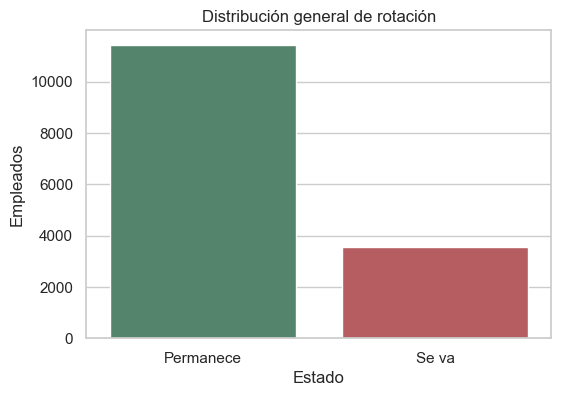

In [5]:
# Dibujamos una grafica sencilla para ver la distribucion de rotacion.
plt.figure(figsize=(6, 4))
sns.barplot(data=rotation_summary, x="estado", y="empleados", hue="estado", palette=["#4c8c6a", "#c44e52"], legend=False)
plt.title("Distribución general de rotación")
plt.xlabel("Estado")
plt.ylabel("Empleados")
plt.show()

## Hipótesis 1: horas mensuales vs satisfacción

- **Variables:** `average_monthly_hours` y `satisfaction_level`.
- **Prueba estadística :** correlación de Pearson
- **H0:** No existe relación lineal estadísticamente significativa entre las horas mensuales promedio y el nivel de satisfacción laboral.
- **H1:** Existe una relación lineal negativa estadísticamente significativa entre las horas mensuales promedio y el nivel de satisfacción laboral.
- **¿Qué se evalúa?:** Se evaluo la relación lineal entre las horas mensuales promedio y el nivel de satisfacción laboral mediante la Correlación de Pearson.


In [9]:
# H1 revisa si existe relacion lineal entre horas mensuales y satisfaccion.
corr, p_value = stats.pearsonr(df["average_monthly_hours"], df["satisfaction_level"])
h1_decision = "Rechazar H0" if p_value < 0.05 else "No rechazar H0"

print(f"Coeficiente r: {corr:.4f}")
print(f"Valor p: {p_value:.6f}")
print("Decision:", h1_decision)

Coeficiente r: -0.0200
Valor p: 0.014075
Decision: Rechazar H0


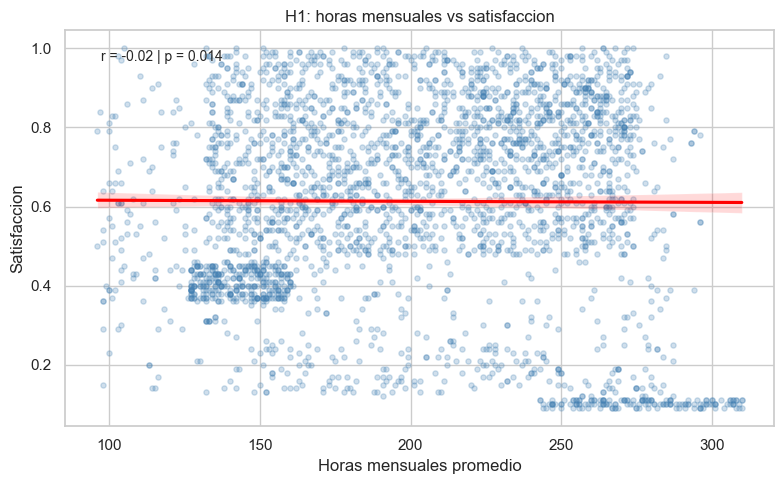

In [11]:
# Graficamos una muestra para ver la tendencia sin saturar la figura.
sample = df.sample(min(len(df), 3000), random_state=42)
plt.figure(figsize=(8, 5))
sns.regplot(
    data=sample,
    x="average_monthly_hours",
    y="satisfaction_level",
    scatter_kws={"alpha": 0.25, "s": 14, "color": "steelblue"},
    line_kws={"color": "red"},
)
plt.title("H1: horas mensuales vs satisfacción")
plt.xlabel("Horas mensuales promedio")
plt.ylabel("Satisfacción")
plt.annotate(
    f"r = {corr:.2f} | p = {p_value:.3f}",
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    fontsize=10,
    va="top",
)
plt.tight_layout()
plt.savefig(VIS_DIR/"h1_horas_vs_satisfaccion.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretación H1 :**
El gráfico de dispersión incluye una línea de tendencia que muestra una pendiente prácticamente plana, confirmando
visualmente la ausencia de relación lineal significativa. Se encontró una correlación negativa muy débil (r = -0.02,
p = 0.014). Aunque estadísticamente significativa debido al tamaño de la muestra (14,999 registros), la magnitud es tan
pequeña que las horas trabajadas no explican de forma relevante la satisfacción del empleado.

## Hipótesis 2: satisfacción baja vs rotación

- **Variables:** `satisfaction_category` y `left`.
- **Prueba estadística:** chi-cuadrado de independencia
- **H0:** La rotación es independiente de la categoria de satisfaccion del empleado.
- **H1:** La rotación depende de la categoria de satisfacción y la salida es mayor en empleados con satisfacción baja.
- **¿Qué se evalúa?:** Se evalua la asociación entre el nivel de satisfacción laboral (Alta/Baja, según la mediana del dataset = 0.64) y la rotación de empleados mediante la prueba Chi-cuadrado de independencia.


In [14]:
# H2 revisa si la satisfaccion baja esta asociada con la salida del empleado.

tabla_sat = pd.crosstab(df["satisfaction_category"], df["left"])
chi2_sat, p_sat, dof_sat, _ = stats.chi2_contingency(tabla_sat)
h2_decision = "Rechazar H0" if p_sat < 0.05 else "No rechazar H0"

display(tabla_sat)
print(f"Chi-cuadrado: {chi2_sat:.4f}")
print(f"Grados de libertad: {dof_sat}")
print(f"Valor p: {p_sat:.6f}")
print("Decisión:", h2_decision)

left,0,1
satisfaction_category,,
Alta,6706,959
Baja,4722,2612


Chi-cuadrado: 1101.5652
Grados de libertad: 1
Valor p: 0.000000
Decisión: Rechazar H0


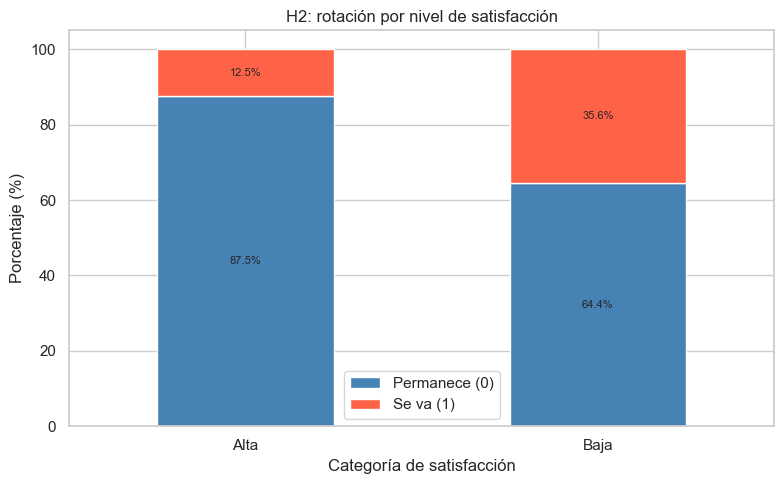

In [16]:
# Convertimos a porcentaje para comparar permanencia y salida dentro de cada grupo.
sat_pct = pd.crosstab(df["satisfaction_category"], df["left_label"], normalize="index").mul(100)
sat_pct[["Permanece", "Se va"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["steelblue", "tomato"],
)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8)
plt.title("H2: rotación por nivel de satisfacción")
plt.xlabel("Categoría de satisfacción")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.legend(["Permanece (0)", "Se va (1)"])
plt.tight_layout()
plt.savefig(VIS_DIR / "h2_satisfaccion_vs_rotacion.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretación H2:**
Las barras apiladas muestran una diferencia clara entre los dos grupos: el 12.5% de empleados con satisfacción alta abandona la
empresa, mientras que el 35.6% de empleados con satisfacción baja la abandona. Se encontró una asociación estadísticamente
significativa (χ² = 1101.57, gl = 1, p < 0.05), por lo que se rechaza H0 y se concluye que la satisfacción laboral se asocia
con la rotación de empleados.

## Hipótesis 3: salario vs rotación

- **Variables:** `salary_label` y `left`.
- **Prueba estadística:** chi-cuadrado de independencia
- **H0:** La rotación es independiente del nivel salarial.
- **H1:** La rotación depende del nivel salarial y es mayor en empleados con salario bajo.
- **¿Qué se evalúa?:** Se evalúa la asociación entre el nivel salarial (Bajo/Medio/Alto) y la rotación de empleados mediante la prueba Chi-cuadrado de independencia.



In [17]:
# H3 revisa si el nivel salarial esta asociado con la rotacion.
tabla_salary = pd.crosstab(df["salary_label"], df["left"])
chi2_salary, p_salary, dof_salary, _ = stats.chi2_contingency(tabla_salary)
h3_decision = "Rechazar H0" if p_salary < 0.05 else "No rechazar H0"

display(tabla_salary)
print(f"Chi-cuadrado: {chi2_salary:.4f}")
print(f"Grados de libertad: {dof_salary}")
print(f"Valor p: {p_salary:.6f}")
print("Decision:", h3_decision)

left,0,1
salary_label,,
Alto,1155,82
Bajo,5144,2172
Medio,5129,1317


Chi-cuadrado: 381.2250
Grados de libertad: 2
Valor p: 0.000000
Decision: Rechazar H0


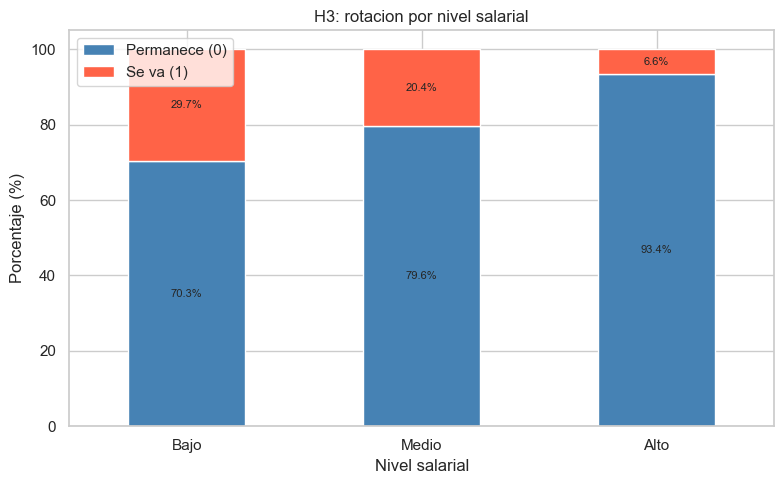

In [18]:
# Pasamos a porcentaje para comparar cada nivel salarial.
salary_pct = pd.crosstab(df["salary_label"], df["left_label"], normalize="index").mul(100)
salary_pct.reindex(["Bajo", "Medio", "Alto"])[["Permanece", "Se va"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["steelblue", "tomato"],
)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8)
plt.title("H3: rotacion por nivel salarial")
plt.xlabel("Nivel salarial")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.legend(["Permanece (0)", "Se va (1)"])
plt.tight_layout()
plt.savefig(VIS_DIR / "h3_salario_vs_rotacion.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretación H3:** El análisis de barras apiladas revela una tendencia clara: a menor nivel salarial, mayor tasa de abandono. Los empleados con salario alto presentan una tasa de rotación del 6.6%, los de salario medio del 20.4% y los de salario bajo del 29.7%.
Esta diferencia fue confirmada estadísticamente (χ² = 381.22, gl = 2, p < 0.05), por lo que se rechaza H0 y se concluye que
existe una asociación significativa entre el nivel salarial y la rotación de empleados.

## Hipótesis 4: departamentos con más horas vs mayor rotación

- **Variables:** `department_label`, `average_monthly_hours` y `left` agregadas por departamento.
- **Prueba estadística:** Correlación de Spearman
- **H0:** No existe una relación monótona estadisticamente significativa entre las horas promedio departamentales y la rotación departamental.
- **H1:** Existe una relación monótona positiva estadísticamente significativa entre las horas promedio departamentales y la rotación departamental.
- **¿Qué se evalúa?:** Se evaluó la relación monotónica entre las horas mensuales promedio por departamento y la tasa de rotación departamental mediante la Correlación de Spearman.


In [22]:
# H4 usa promedios exactos por departamento antes de redondear.
department = (
    df.groupby(["department", "department_label"], as_index=False)
    .agg(
        employees=("employee_count", "sum"),
        avg_monthly_hours=("average_monthly_hours", "mean"),
        turnover_rate=("left", "mean"),
        avg_satisfaction=("satisfaction_level", "mean"),
    )
    .sort_values("turnover_rate", ascending=False)
)
department["turnover_rate_pct"] = department["turnover_rate"].mul(100)
spearman, p_dept = stats.spearmanr(department["avg_monthly_hours"], department["turnover_rate"])
h4_decision = "Rechazar H0" if p_dept < 0.05 else "No rechazar H0"

display(
    department[["department_label", "employees", "avg_monthly_hours", "turnover_rate_pct", "avg_satisfaction"]]
    .round({"avg_monthly_hours": 1, "turnover_rate_pct": 2, "avg_satisfaction": 3})
)
print(f"Spearman rho: {spearman:.4f}")
print(f"Valor p: {p_dept:.6f}")
print("Decision:", h4_decision)

,department_label,employees,avg_monthly_hours,turnover_rate_pct,avg_satisfaction
3,Recursos Humanos,739,198.7,29.09,0.599
2,Contabilidad,767,201.2,26.60,0.582
9,Tecnico,2720,202.5,25.62,0.608
8,Soporte,2229,200.8,24.90,0.618
7,Ventas,4140,200.9,24.49,0.614
5,Marketing,858,199.4,23.66,0.619
0,IT,1227,202.2,22.25,0.618
6,Producto,902,200.0,21.95,0.620
1,I+D,787,200.8,15.37,0.620
4,Gerencia,630,201.2,14.44,0.621


Spearman rho: -0.1515
Valor p: 0.676065
Decision: No rechazar H0


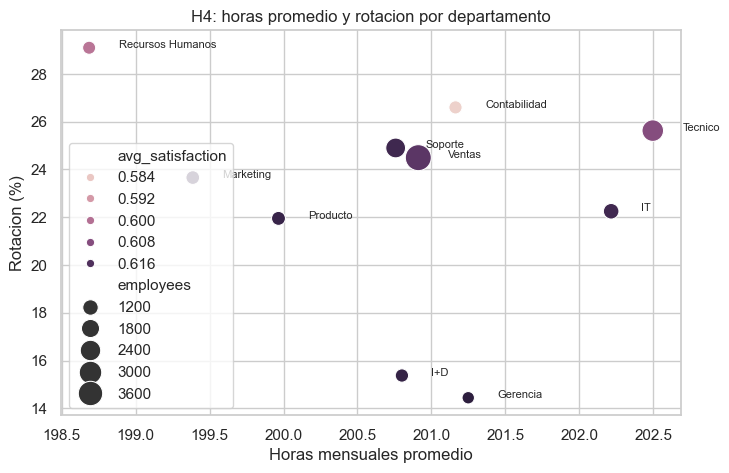

In [23]:
# Graficamos cada departamento para comparar horas promedio y rotacion.
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=department,
    x="avg_monthly_hours",
    y="turnover_rate_pct",
    size="employees",
    hue="avg_satisfaction",
    sizes=(80, 350),
)
for _, row in department.iterrows():
    plt.text(row["avg_monthly_hours"] + 0.2, row["turnover_rate_pct"], row["department_label"], fontsize=8)
plt.title("H4: horas promedio y rotacion por departamento")
plt.xlabel("Horas mensuales promedio")
plt.ylabel("Rotacion (%)")
plt.savefig(VIS_DIR / "h4_departamentos_mashoras_vs_mayor_rotacion.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación H4:** Se encontró una correlación negativa muy débil (rho = -0.15,p = 0.676), por lo que no se rechaza H0. No existe evidencia estadísticamente significativa de que los departamentos con mayor carga horaria presenten mayor rotación.

## Exportacion de resultados y matriz de hipotesis


In [24]:
resultados = pd.DataFrame(
    [
        [
            "H1",
            "Horas mensuales vs satisfaccion",
            "average_monthly_hours, satisfaction_level",
            "No existe relacion lineal estadisticamente significativa entre las horas mensuales promedio y el nivel de satisfaccion laboral.",
            "Existe una relacion lineal negativa estadisticamente significativa entre las horas mensuales promedio y el nivel de satisfaccion laboral.",
            "Permite identificar si la carga de trabajo excesiva esta afectando directamente la satisfaccion laboral, lo que podria ser una senal temprana de burnout. Si se confirma, RRHH podria proponer redistribuir la carga de trabajo y revisar el numero de proyectos asignados para prevenir el burnout y reducir el riesgo de rotacion.",
            "Correlacion de Pearson",
            round(float(corr), 4),
            round(float(p_value), 6),
            None,
            h1_decision,
            "Se encontro una correlacion negativa muy debil (r = -0.02, p = 0.014). Aunque estadisticamente significativa debido al tamano de la muestra (14,999 registros), la magnitud es tan pequena que las horas trabajadas no explican de forma relevante la satisfaccion del empleado. Esta hipotesis actua como paso previo a H2: si mas horas reducen satisfaccion, y H2 confirma que baja satisfaccion aumenta rotacion, la carga laboral seria un factor indirecto de rotacion.",
        ],
        [
            "H2",
            "Satisfaccion baja vs rotacion",
            "satisfaction_category, left",
            "La rotacion es independiente de la categoria de satisfaccion del empleado.",
            "La rotacion depende de la categoria de satisfaccion y la salida es mayor en empleados con satisfaccion baja.",
            "Permite identificar anticipadamente que empleados tienen baja satisfaccion y mayor riesgo de irse, ya que puede costarle a la empresa tiempo de reclutamiento, entrenamiento del nuevo empleado y productividad perdida. Si se confirma, RRHH podria implementar programas de bienestar, bonificaciones y reconocimientos para mejorar la satisfaccion del empleado.",
            "Chi-cuadrado de independencia",
            round(float(chi2_sat), 4),
            round(float(p_sat), 6),
            int(dof_sat),
            h2_decision,
            "Se encontro una asociacion estadisticamente significativa (chi2 = 1101.57, gl = 1, p < 0.05). El 35.6% de empleados con satisfaccion baja abandona la empresa frente al 12.5% con satisfaccion alta. Los empleados con satisfaccion baja tienen aproximadamente el triple de probabilidad de abandonar la empresa, lo que sugiere que intervenir el clima laboral podria reducir significativamente la rotacion.",
        ],
        [
            "H3",
            "Salario vs rotacion",
            "salary_label, left",
            "La rotacion es independiente del nivel salarial.",
            "La rotacion depende del nivel salarial y es mayor en empleados con salario bajo.",
            "Permite identificar que tipo de salario reciben los empleados que se quedan frente a los que se van, lo que refleja si la empresa es competitiva en el mercado laboral. Si se confirma, RRHH podria implementar ajustes de compensacion por mercado y politica de incrementos salariales periodicos para reducir la rotacion.",
            "Chi-cuadrado de independencia",
            round(float(chi2_salary), 4),
            round(float(p_salary), 6),
            int(dof_salary),
            h3_decision,
            "Se encontro una asociacion estadisticamente significativa (chi2 = 381.22, gl = 2, p < 0.05). A menor nivel salarial, mayor tasa de abandono: salario alto 6.6%, medio 20.4%, bajo 29.7%. Los empleados con salario bajo tienen aproximadamente 4.5 veces mas probabilidad de abandonar la empresa que los de salario alto.",
        ],
        [
            "H4",
            "Horas promedio departamentales vs rotacion departamental",
            "department_label, average_monthly_hours, left",
            "No existe una relacion monotona estadisticamente significativa entre las horas promedio departamentales y la rotacion departamental.",
            "Existe una relacion monotona positiva estadisticamente significativa entre las horas promedio departamentales y la rotacion departamental.",
            "Permite validar si la sobrecarga operativa por departamento explica la salida y si conviene intervenir equipos especificos. Si se confirma, RRHH podria alertar a los lideres de cada area sobre la distribucion de carga de trabajo.",
            "Correlacion de Spearman",
            round(float(spearman), 4),
            round(float(p_dept), 6),
            None,
            h4_decision,
            "No se rechaza H0 (rho = -0.15, p = 0.676). No existe evidencia estadisticamente significativa de que los departamentos con mayor carga horaria presenten mayor rotacion. Las horas promedio son muy similares entre departamentos (aproximadamente 200 horas), lo que explica la ausencia de correlacion. Otros factores como satisfaccion laboral y salario tienen mayor peso explicativo.",
        ],
    ],
    columns=[
        "hipotesis",
        "tema",
        "variables",
        "h0",
        "h1",
        "justificacion_negocio",
        "prueba",
        "estadistico",
        "valor_p",
        "grados_libertad",
        "decision",
        "interpretacion",
    ],
)

resultados.to_csv(REPORTS_DIR / "resultados_hipotesis.csv", index=False, encoding="utf-8")
display(resultados)

,hipotesis,tema,variables,h0,h1,justificacion_negocio,prueba,estadistico,valor_p,grados_libertad,decision,interpretacion
0,H1,Horas mensuales vs satisfaccion,"average_monthly_hours, satisfaction_level",No existe relacion lineal estadisticamente sig...,Existe una relacion lineal negativa estadistic...,Permite identificar si la carga de trabajo exc...,Correlacion de Pearson,-0.0200,0.014075,NaN,Rechazar H0,Se encontro una correlacion negativa muy debil...
1,H2,Satisfaccion baja vs rotacion,"satisfaction_category, left",La rotacion es independiente de la categoria d...,La rotacion depende de la categoria de satisfa...,Permite identificar anticipadamente que emplea...,Chi-cuadrado de independencia,1101.5652,0.000000,1.0,Rechazar H0,Se encontro una asociacion estadisticamente si...
2,H3,Salario vs rotacion,"salary_label, left",La rotacion es independiente del nivel salarial.,La rotacion depende del nivel salarial y es ma...,Permite identificar que tipo de salario recibe...,Chi-cuadrado de independencia,381.2250,0.000000,2.0,Rechazar H0,Se encontro una asociacion estadisticamente si...
3,H4,Horas promedio departamentales vs rotacion dep...,"department_label, average_monthly_hours, left",No existe una relacion monotona estadisticamen...,Existe una relacion monotona positiva estadist...,Permite validar si la sobrecarga operativa por...,Correlacion de Spearman,-0.1515,0.676065,NaN,No rechazar H0,"No se rechaza H0 (rho = -0.15, p = 0.676). No ..."
